# Early warning system for COVID-19 pandemic

- **Training style**: One-leave-out cross-validation (LOOCV):

    + Train the model on 231 countries and test on one remaining country.

    + Plot the survival curve for tested country.

- **Evaluation**:
    
    + *Concordance index (C-index)*: measures the discriminative power of the model. A C-index of 0.5 indicates no discriminative power, while a C-index of 1 indicates perfect discrimination.

    + *Brier score*: measures the accuracy of probabilistic predictions. A Brier score of 0 indicates perfect accuracy, while a Brier score of 1 indicates the worst possible accuracy.

- **Early warning system**: The target is to build a system capable of warning countries about potential RED transformations. Different strategies are tested to achieve this goal, including:

    + *Fixed-threshold strategy*: A country is warned if its predicted probability of RED transformation exceeds a fixed threshold (e.g., 0.8, 0.2).

    + *Monitoring window*: Using relative change of the survival probability over the k-day period preceding to monitor the risk of RED transformation. Specifically, if the relative change exceeds a certain threshold, the country is warned.

    + *Risk velocity*: Using the first derivative of the survival probability to monitor the risk of RED transformation. If the risk velocity exceeds a certain threshold, the country is warned.

$\Rightarrow$ The result demonstrates that the monitoring window strategy is the most effective in warning countries about potential RED transformations, as it gives the highest warning performance, i.e. balanced between true positive rate (TPR), false positive rate (FPR) and the average lead time from the warning date to the actual RED transformation date.

## 1. Dataset Preparation
### 1.1 Import dataset

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime

from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from itertools import product

dir_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.model import fitting_model, format_data

In [2]:
tdp_path = os.path.join(dir_path, 'time-dependent-variables-MissForest.csv')
idp_path = os.path.join(dir_path, 'time-independent-variables-MissForest.csv')

tdp_df = pd.read_csv(tdp_path, usecols=["iso_code", "total_tests_per_thousand", 
                                                                  "people_fully_vaccinated_per_hundred", 
                                                                  "stringency_index", "status", "days"])

idp_df = pd.read_csv(idp_path)
idp_df = idp_df.drop(columns=["location", "Overall_score"], axis=0)

tdp_df.info(), idp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156613 entries, 0 to 156612
Data columns (total 6 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   iso_code                             156613 non-null  object 
 1   total_tests_per_thousand             156613 non-null  float64
 2   people_fully_vaccinated_per_hundred  156613 non-null  float64
 3   stringency_index                     156613 non-null  float64
 4   days                                 156613 non-null  int64  
 5   status                               156613 non-null  bool   
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iso_code        232 non-null    object 
 1   continent       232 non-null    object 

(None, None)

In [3]:
idp_df['duration'] = idp_df['duration'] + 1
tdp_df['days'] = tdp_df['days'] - 1

### 1.2 Dataset pre-processing

In [4]:
# deal with datetime
def convertDate(row):
    try:
        year, month, day  = row.split('-')
        return datetime.datetime(int(year), int(month), int(day))
    except:
        return row
    
# deal with category data
def autoCategory(df: pd.DataFrame, cols: list):
    for col in cols:
        items = df[col].unique()
        for idx, item in enumerate(items):
            if idx == len(items) - 1:
                break
            df[f"{col}_{item}"] = df[col].apply(lambda x: 1 if x == item else 0)

    return df.drop(columns=cols, axis=1)

# convert first_case to days from min first_case
def convertFirstDate(row):
    return row["first_case"] - min_date

idp_df["first_case"] = idp_df["first_case"].apply(convertDate)
min_date = idp_df["first_case"].unique().min()
idp_df["start_date"] = (idp_df["first_case"] - min_date).dt.days
idp_df = idp_df.drop(columns=["first_case"], axis=0)

dummy_cols = [x for x in idp_df.columns if idp_df[x].dtypes == "object" and x not in ["iso_code", "location"]]
idp_df = autoCategory(idp_df, dummy_cols)
idp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            232 non-null    object 
 1   population                          232 non-null    float64
 2   median_age                          232 non-null    float64
 3   duration                            232 non-null    int64  
 4   status                              232 non-null    bool   
 5   start_date                          232 non-null    int64  
 6   continent_North America             232 non-null    int64  
 7   continent_Asia                      232 non-null    int64  
 8   continent_Africa                    232 non-null    int64  
 9   continent_Europe                    232 non-null    int64  
 10  continent_South America             232 non-null    int64  
 11  classification_HIGH-INCOME          232 non-n

### 1.3 K-fold cross-validation

- When `n_splits = number of samples`, it becomes leave-one-out (LOO) cross-validation, which is more suitable for small datasets.

In [ ]:
def model_kfold_split(timedp_df: pd.DataFrame, indp_df: pd.DataFrame, n_splits: int, random_state: int):
    """
    Return: tuple of idp list of folds + tdp list of folds
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    idp_folds = []
    tdp_folds = []

    X = indp_df
    y = indp_df["status"]

    for train_index, test_index in skf.split(X, y):
        indp_train = X.iloc[train_index].copy()
        indp_test = X.iloc[test_index].copy()

        # Get the unique iso_codes for training
        train_iso_list = indp_train["iso_code"].drop_duplicates().tolist()

        # Mark the time series data for training or testing
        timedp_df["train"] = timedp_df["iso_code"].isin(train_iso_list)
        timedp_train = timedp_df[timedp_df["train"] == True].copy().drop(columns=["train"])
        timedp_test = timedp_df[timedp_df["train"] == False].copy().drop(columns=["train"])

        idp_folds.append((indp_train, indp_test))
        tdp_folds.append((timedp_train, timedp_test))
    
    return idp_folds, tdp_folds

### 1.5 Leave-one-out (LOO) cross-validation

In [6]:
def model_leave_one_out_split(timedp_df: pd.DataFrame, indp_df: pd.DataFrame):
    idp_folds = []
    tdp_folds = []

    for idx in range(len(indp_df)):
        indp_train = indp_df.drop(index=idx).copy()
        indp_test = indp_df.iloc[idx:idx+1].copy()

        # Get the unique iso_codes for training
        train_iso_list = indp_train["iso_code"].drop_duplicates().tolist()

        # Mark the time series data for training or testing
        timedp_df["train"] = timedp_df["iso_code"].isin(train_iso_list)
        timedp_train = timedp_df[timedp_df["train"] == True].copy().drop(columns=["train"])
        timedp_test = timedp_df[timedp_df["train"] == False].copy().drop(columns=["train"])

        idp_folds.append((indp_train, indp_test))
        tdp_folds.append((timedp_train, timedp_test))
    
    return idp_folds, tdp_folds

## 2. Score function

### 2.1 Survival probability prediction function

In [ ]:
def compute_survival_probabilities(
        model, subject_df: pd.DataFrame
    ) -> pd.DataFrame:
    """
    Compute survival probabilities over time for a subject.
    Return a dataframe with columns: "time", "survival_probability".
    """
    baseline_cumulative_hazard = model.baseline_cumulative_hazard_

    ## if the end date of the subject is not in the baseline cumulative hazard, we need to append it to the baseline cumulative hazard with the same value as the nearest existing date.
    subject_end_date = subject_df["stop"].max()
    if subject_end_date not in baseline_cumulative_hazard.index:
        # Find the nearest date in the baseline cumulative hazard
        nearest_date = baseline_cumulative_hazard.index[baseline_cumulative_hazard.index <= subject_end_date].max()
        if pd.isna(nearest_date):
            nearest_date = baseline_cumulative_hazard.index.min()
        # Append the new date with the same hazard value
        baseline_cumulative_hazard.loc[subject_end_date] = baseline_cumulative_hazard.loc[nearest_date]

    columns = model.params_.index.values
    beta = model.params_.values

    times = baseline_cumulative_hazard.index.values
    H0 = baseline_cumulative_hazard.values.flatten()

    delta_H0 = np.diff(np.insert(H0, 0, 0))

    H_i = 0
    results = [(0, 1.0)]  # Start with time 0 and survival probability 1

    for t_k, dH0_k in zip(times, delta_H0):
        # find covariate value at time t_k
        row = subject_df[(subject_df["start"] <= t_k) & (subject_df["stop"] >= t_k)]

        if row.empty:
            if not results:
                results.append((t_k, 1.0))  # If no data is available, assume survival probability is 1
            break

        risk = np.exp(row[columns].values @ beta)[0]

        H_i += risk * dH0_k

        results.append((t_k, np.exp(-H_i)))

    return pd.DataFrame(results, columns=["time", "survival_probability"])

### 2.2 Brier score calculation

In [ ]:
def brier_score(model, cp_df: pd.DataFrame):
    arr = np.array([
            (
                compute_survival_probabilities(model, cp_df[cp_df["iso_code"] == country]).iloc[-1]["survival_probability"],
                idp_df.loc[idp_df["iso_code"] == country, "status"].iloc[0]
            ) for country in cp_df["iso_code"].unique()])

    return np.mean((1 - arr[:, 0] - arr[:, 1]) ** 2)     # baseline case: 0.5 for each country, loss = 0.25

### 2.3 C-index calculation

In [8]:
def c_index(idp_df: pd.DataFrame, survival_probabilities_dict: dict[str, pd.DataFrame]):
    """
    Compute the C-index for the given survival probabilities and the true status in idp_df.
    """
    sorted_idp_df = idp_df.sort_values(by="status", ascending=False).copy()
    sorted_idp_df.sort_values(by="duration", inplace=True)
    sorted_idp_df.reset_index(drop=True, inplace=True)

    concordant = 0
    num_pairs = 0

    for i in range(len(sorted_idp_df)):
        if sorted_idp_df.loc[i, "status"] == 0:     # in case censoring => skip
            continue

        iso_i = sorted_idp_df.loc[i, "iso_code"]
        event_time = sorted_idp_df.loc[i, "duration"]

        # get survival probability at event_time for iso_i
        try:
            surv_i = survival_probabilities_dict[iso_i][survival_probabilities_dict[iso_i]["time"] <= event_time].iloc[-1]["survival_probability"]
        except IndexError as e:
            surv_i = 1.0

        for j in range(i + 1, len(sorted_idp_df)):
            num_pairs += 1

            iso_j = sorted_idp_df.loc[j, "iso_code"]
            # get survival probability at event_time for iso_j
            try:
                surv_j = survival_probabilities_dict[iso_j][survival_probabilities_dict[iso_j]["time"] <= event_time].iloc[-1]["survival_probability"]
            except IndexError as e:
                surv_j = 1.0

            if surv_i < surv_j:
                concordant += 1
            elif surv_i == surv_j:
                concordant += 0.5
            

    return concordant / num_pairs if num_pairs > 0 else 0

## 2. Train model

### 2.1 Setup aggregate for grouping dataset

In [9]:
agg_functions = dict()
agg_functions["total_tests_per_thousand"] = 'max'
agg_functions["people_fully_vaccinated_per_hundred"] = 'max'
agg_functions["stringency_index"] = 'mean'
agg_functions["days"] = "min"
agg_functions["status"] = "max"

cutting_points = [240, 1030]
l1_penalized, l2_penalized = 0.56, 0.05

### 2.2 Leave-one-out (LOO)

- **Leave-one-out (LOO)**: 
    + Each sample is used once as a test set while 
    + The remaining samples form the training set
    + Evaluation metrics: C-index, Brier score.

**Problem with LOO + C-index**: can not directly compute C-index for each fold since we only have one test sample.

In [10]:
num_of_samples = len(idp_df)

idp_folds, tdp_folds = model_leave_one_out_split(tdp_df.copy(), idp_df.copy())

print(f"Number of folds: {len(idp_folds)}")

Number of folds: 232


### 2.3 Train model

In [ ]:
brier_score_lst = []
survival_probabilities_dict: dict[str, pd.DataFrame] = {}

for (indp_train, indp_test), (tdp_train, tdp_test) in tqdm(zip(idp_folds, tdp_folds), total=num_of_samples, desc="LOO cross-validation"):
    model, scaler = fitting_model(tdp_train, indp_train, agg_functions, cutting_points, 
                                l2_penalized, l1_penalized, tdp_effect=True, normalized=True)
    
    test_cp_df, _ = format_data(tdp_test, indp_test, agg_functions, cutting_points, 
                                               tdp_effect=True, scaler=scaler, normalized=True)
    
    survival_probabilities_dict[indp_test["iso_code"].iloc[0]] = compute_survival_probabilities(model, test_cp_df)
    
    brier_score_value = brier_score(model, test_cp_df)
    brier_score_lst.append(brier_score_value)

C_index_value = c_index(idp_df, survival_probabilities_dict)

print(f"Brier score: {sum(brier_score_lst) / len(brier_score_lst)}")
print(f"C-index: {C_index_value}")

LOO cross-validation:  66%|██████▌   | 153/232 [06:56<03:45,  2.86s/it]/opt/anaconda3/envs/Env_for_pytorch/lib/python3.9/site-packages/lifelines/fitters/cox_time_varying_fitter.py:494: ConvergenceWarning: Newton-Raphson failed to converge sufficiently in 50 steps.
  warnings.warn("Newton-Raphson failed to converge sufficiently in %d steps." % max_steps, ConvergenceWarning)
LOO cross-validation:  85%|████████▌ | 198/232 [08:58<01:29,  2.64s/it]/opt/anaconda3/envs/Env_for_pytorch/lib/python3.9/site-packages/lifelines/fitters/cox_time_varying_fitter.py:494: ConvergenceWarning: Newton-Raphson failed to converge sufficiently in 50 steps.
  warnings.warn("Newton-Raphson failed to converge sufficiently in %d steps." % max_steps, ConvergenceWarning)
LOO cross-validation:  91%|█████████▏| 212/232 [09:37<00:55,  2.77s/it]/opt/anaconda3/envs/Env_for_pytorch/lib/python3.9/site-packages/lifelines/fitters/cox_time_varying_fitter.py:494: ConvergenceWarning: Newton-Raphson failed to converge sufficien

Brier score: 0.30343321852787225
C-index: 0.8108010439670749


## 3. Model evaluation

### 3.1 Survival curves

Mark ZWE endpoint: 100%|██████████| 232/232 [00:00<00:00, 238.49it/s]     


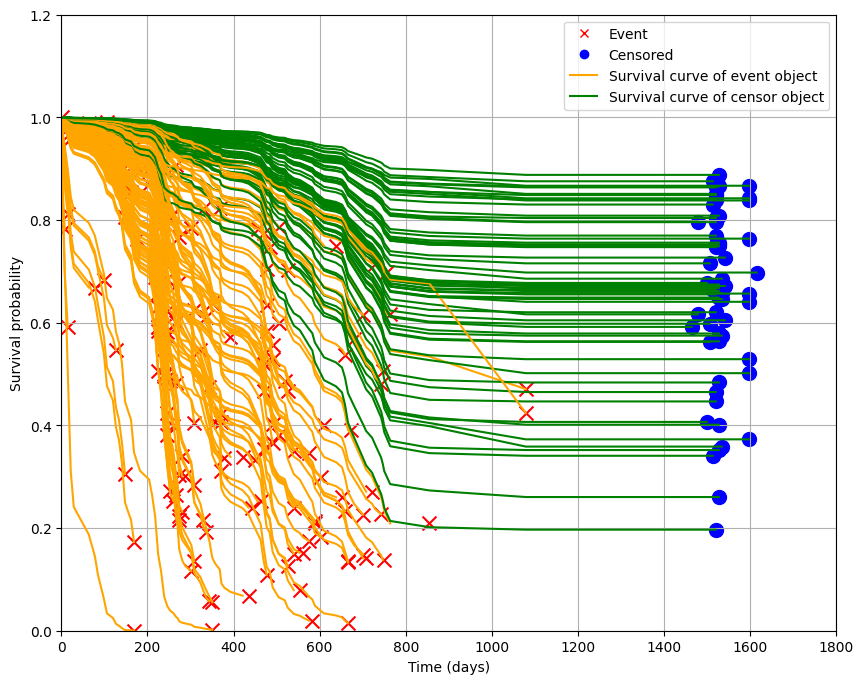

In [ ]:
plt.figure(figsize=(10, 8))

pbar = tqdm(survival_probabilities_dict.items(), desc="Plotting survival curves")

for iso_code, surv_df in pbar:
    pbar.set_description(f"Plot {iso_code} curve")

    # Plot end point:
    ## Case 1: event occurs => red cross
    ## Case 2: censored => blue circle
    row = idp_df[idp_df["iso_code"] == iso_code].iloc[0]
    status, duration = row["status"], row["duration"]
    end_date_survival = surv_df.iloc[-1]["survival_probability"]
    
    line_color, end_point_color, end_point_shape = ("orange", "red", "x") if status else ("green", "blue", "o")

    plt.plot(surv_df["time"], surv_df["survival_probability"], label=iso_code, color=line_color)
    plt.scatter(x=duration, y=end_date_survival, marker=end_point_shape,
                c=end_point_color, label="Event" if status else "censored", s=80)

plt.ylim([0, 1.2])
plt.xlim([0, 1800])

legend_elements = [
    plt.Line2D([0], [0], marker='x', color='red', linestyle='None', label='Event'),
    plt.Line2D([0], [0], marker='o', color='blue', linestyle='None', label='Censored'),
    plt.Line2D([], [], color="orange", label="Survival curve of event object"),
    plt.Line2D([], [], color="green", label="Survival curve of censor object")
]

plt.legend(handles=legend_elements)
# plt.title("Survival curves for each country")
plt.xlabel("Time (days)")
plt.ylabel("Survival probability")

plt.grid()
plt.show()

### 3.2 Brier score

- **Idea**: classify countries into 8 groups with 2 classification stages:

    + Event vs. Censoring
    + Survival probability by the end date: 4 groups (0-25%, 25-50%, 50-75%, 75-100%)

- **Ideal cases**:
    + Event in group 1 (subject is prediced to have a low survival probability at the event date)
    + Subject in group 4 (subject is predicted to have a high survival probability at the censored date)

In [16]:
event_groups = [0, 0, 0, 0]
censor_groups = [0, 0, 0, 0]

event_brier_score_lst, censor_brier_score_lst = [], []


for (iso_code, surv_df), score in zip(survival_probabilities_dict.items(), brier_score_lst):
    row = idp_df[idp_df["iso_code"] == iso_code].iloc[0]

    # Categorize based on status and survival probability
    if row["status"] == 1:  # Event
        event_brier_score_lst.append(score)

        if surv_df.iloc[-1]["survival_probability"] < 0.25:
            event_groups[0] += 1
        elif surv_df.iloc[-1]["survival_probability"] < 0.5:
            event_groups[1] += 1
        elif surv_df.iloc[-1]["survival_probability"] < 0.75:
            event_groups[2] += 1
        else:
            event_groups[3] += 1
    else:  # Censoring
        censor_brier_score_lst.append(score)

        if surv_df.iloc[-1]["survival_probability"] < 0.25:
            censor_groups[0] += 1
        elif surv_df.iloc[-1]["survival_probability"] < 0.5:
            censor_groups[1] += 1
        elif surv_df.iloc[-1]["survival_probability"] < 0.75:
            censor_groups[2] += 1
        else:
            censor_groups[3] += 1

print(f"| Status \t| Group 1 (0-25%) \t| Group 2 (25-50%) \t| Group 3 (50-75%) \t| Group 4 (75-100%) \t| Brier score \t|")
print(f"| --- \t\t| --- \t\t\t| --- \t\t\t| --- \t\t\t| --- \t\t\t|")
print(f"| Event \t| {event_groups[0]} \t\t\t| {event_groups[1]} \t\t\t| {event_groups[2]} \t\t\t| {event_groups[3]} \t\t\t| {np.mean(event_brier_score_lst):.4f} \t|")
print(f"| Censoring \t| {censor_groups[0]} \t\t\t| {censor_groups[1]} \t\t\t| {censor_groups[2]} \t\t\t| {censor_groups[3]} \t\t\t| {np.mean(censor_brier_score_lst):.4f} \t|")

| Status 	| Group 1 (0-25%) 	| Group 2 (25-50%) 	| Group 3 (50-75%) 	| Group 4 (75-100%) 	| Brier score 	|
| --- 		| --- 			| --- 			| --- 			| --- 			|
| Event 	| 35 			| 43 			| 45 			| 47 			| 0.3602 	|
| Censoring 	| 1 			| 10 			| 31 			| 20 			| 0.1479 	|


## 4. Model inference - Early warning system

We test 3 approaches for early warning system, namely *fixed threshold*, *dynamic threshold*, and *risk velocity*. The result demonstrates that *dynamic threshold* is the most effective approach for early warning system.

### 4.1 Fixed threshold

- **Idea**: As a country survival probability drops under a predefined threshold, we can issue a warning for that country.

- **Evaluation**:
    + *Event detection rate*: Number of detected events / Total number of events

    + *False alarm rate*: Number of failed-detected alarms / Total number of censored cases

    + *Average lead time*: Average number of days between the warning date and the event date for detected events.

In [48]:
# Then we count number of detected event cases and miss-warning of censor cases
def interpolate_warning_day(surv_df: pd.DataFrame, threshold: float) -> float:
    """
    Interpolate the warning day for the given survival probability threshold.
    """
    # Find the first time where survival probability drops below the threshold
    below_threshold = surv_df[surv_df["survival_probability"] < threshold]
    
    if below_threshold.empty:
        return None  # No warning day found
    
    first_below = below_threshold.iloc[0]
    
    # Get the previous point
    prev_point = surv_df[surv_df["time"] < first_below["time"]].iloc[-1]
    
    # Linear interpolation to find the exact warning day
    x0, y0 = prev_point["time"], prev_point["survival_probability"]
    x1, y1 = first_below["time"], first_below["survival_probability"]
    
    if y1 == y0:
        return x1  # Avoid division by zero, return the next time point
    
    warning_day = x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)
    
    return warning_day

event_rows = idp_df[idp_df["status"] == 1]
censor_rows = idp_df[idp_df["status"] == 0]

THRESHOLD = 0.75
positive_cases = 0
negative_cases = 0
lead_times = []

for idx, row in event_rows.iterrows():
    iso_code = row["iso_code"]
    duration = row['duration']
    last_surv_prob = survival_probabilities_dict[iso_code].iloc[-1]["survival_probability"]
    if last_surv_prob < THRESHOLD:
        # get the warning day for the threshold
        duration_threshold = interpolate_warning_day(survival_probabilities_dict[iso_code], THRESHOLD)
        positive_cases += 1
        lead_times.append(duration - duration_threshold)

for idx, row in censor_rows.iterrows():
    iso_code = row["iso_code"]
    last_surv_prob = survival_probabilities_dict[iso_code].iloc[-1]["survival_probability"]
    if last_surv_prob < THRESHOLD:
        negative_cases += 1

event_detected_rate = positive_cases / len(event_rows)
censor_miss_warning_rate = negative_cases / len(censor_rows)

print(f"Event detected rate: {event_detected_rate:.2%}")
print(f"False alarms rate: {censor_miss_warning_rate:.2%}")
print(f"Average lead time: {np.mean(lead_times):.2f}")

Event detected rate: 72.35%
False alarms rate: 67.74%
Average lead time: 168.40


### 4.2 The k-day monitoring window

- **Idea**: Modeling the risk score $R(t, k)$ at time $t$ is defined as the relative increase in predicted risk over the preceding $k$ days:
$$ R(t, k) = 1 - \frac{S(t)}{S(t-k)} $$

- **Hyperparameters**:

    + Threshold: the threshold for issuing a warning

    + K: the number of days to look ahead for the event

In [ ]:
def interpolate_prob_day(surv_df: pd.DataFrame, t: int) -> float:
    """
    Interpolate the survival probability at time t.
    """
    # Find the first time where survival probability is less than or equal to t
    below_t = surv_df[surv_df["time"] <= t]
    
    if below_t.empty:
        return None  # No data available for interpolation
    
    first_below = below_t.iloc[-1]

    if first_below["time"] == t:
        return first_below["survival_probability"]  # Exact match, return the known probability
    
    # Get the next point
    next_point = surv_df[surv_df["time"] > first_below["time"]].iloc[0] if not surv_df[surv_df["time"] > first_below["time"]].empty else None
    
    if next_point is None:
        return first_below["survival_probability"]  # No next point, return the last known probability
    
    # Linear interpolation to find the exact survival probability at time t
    x0, y0 = first_below["time"], first_below["survival_probability"]
    x1, y1 = next_point["time"], next_point["survival_probability"]
    
    if x1 == x0:
        return y0  # Avoid division by zero, return the known probability
    
    interpolated_prob = y0 + (t - x0) * (y1 - y0) / (x1 - x0)
    
    return interpolated_prob

def compute_risk_score(surv_df: pd.DataFrame, t: int, k: int = 30):
    """
    Compute the conditional event probability over the next k days:
    P(T < t+k | T >= t) = 1 - S(t + k) / S(t)
    """
    S_t = interpolate_prob_day(surv_df, t)
    S_t_k = interpolate_prob_day(surv_df, t + k)

    # print(f"S({t}) = {S_t:.3f}, S({t + k}) = {S_t_k:.3f}")

    conditional_prob = 1 - (S_t_k / S_t)
    
    return conditional_prob

In [ ]:
k_list = [1, 7, 10, 14, 30, 40, 50, 60, 90, 100]
threshold_lists = [0.01, 0.03, 0.06, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]

result_dict = {}

for THRESHOLD, K in tqdm(product(threshold_lists, k_list), total=len(threshold_lists) * len(k_list), desc="Processing thresholds and K values"):
    positive_cases = 0
    negative_cases = 0
    lead_times = []

    # for idx, row in tqdm(event_rows.iterrows(), total=len(event_rows), desc="Processing event rows"):
    for idx, row in event_rows.iterrows():
        iso_code = row["iso_code"]
        duration = row['duration']
        start_days = range(0, duration, max([K, 30]))   # Use max(K, 30) to avoid high computational cost for small K values
        for start_day in start_days:
            conditional_prob = compute_risk_score(survival_probabilities_dict[iso_code], start_day, k=K)
            if conditional_prob > THRESHOLD:
                positive_cases += 1
                lead_times.append(duration - start_day - K)
                break

    # for idx, row in tqdm(censor_rows.iterrows(), total=len(censor_rows), desc="Processing censor rows"):
    for idx, row in censor_rows.iterrows():
        iso_code = row["iso_code"]
        duration = row['duration']
        start_days = range(0, duration, max([K, 30]))   # Use max(K, 30) to avoid high computational cost for small K values
        for start_day in start_days:
            conditional_prob = compute_risk_score(survival_probabilities_dict[iso_code], start_day, k=K)
            if conditional_prob > THRESHOLD:
                negative_cases += 1
                break

    event_detected_rate = positive_cases / len(event_rows)
    censor_miss_warning_rate = negative_cases / len(censor_rows)

    result_dict[(THRESHOLD, K)] = {
        "event_detected_rate": event_detected_rate,
        "censor_miss_warning_rate": censor_miss_warning_rate,
        "average_lead_time": np.mean(lead_times) if lead_times else None
    }

result_df = pd.DataFrame(result_dict).T
result_df.columns = ["Event detected rate", "False alarms rate", "Average lead time"]
result_df

Processing thresholds and K values:  36%|███▌      | 50/140 [02:16<02:59,  1.99s/it]/opt/anaconda3/envs/Env_for_pytorch/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Env_for_pytorch/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
Processing thresholds and K values: 100%|██████████| 140/140 [07:56<00:00,  3.40s/it]


Event detected rate  False alarms rate  Average lead time
0.01 1               0.364706           0.016129          75.870968
     7               0.900000           0.774194         217.823529
     10              0.911765           0.822581         258.580645
     14              0.935294           0.870968         280.056604
     30              0.988235           1.000000         302.494048
...                       ...                ...                ...
0.55 40              0.035294           0.000000          58.166667
     50              0.064706           0.000000          46.454545
     60              0.070588           0.000000          50.583333
     90              0.117647           0.000000          35.100000
     100             0.147059           0.000000          22.560000

[140 rows x 3 columns]

In [142]:
# Soft threshold: check FAR of those with event detected rate > 0.8, and find the one with lowest FAR
filtered_df = result_df[result_df["Event detected rate"] > 0.8]

filtered_df = filtered_df.sort_values(by="False alarms rate", ascending=True)

print(f"Filtered result with Event detected rate > 0.8, sorted by False alarms rate:")

display(filtered_df.head(5))

# Hard threshold: check those with FAR < 0.05, and find the one with highest event detected rate
filtered_df_hard = result_df[result_df["False alarms rate"] < 0.05]

filtered_df_hard = filtered_df_hard.sort_values(by="Event detected rate", ascending=False)

print(f"Filtered result with False alarms rate < 0.05, sorted by Event detected rate:")
display(filtered_df_hard.head(10))

Filtered result with Event detected rate > 0.8, sorted by False alarms rate:


Event detected rate  False alarms rate  Average lead time
0.100 100             0.805882           0.548387         142.116788
      120             0.811765           0.580645         158.304348
      140             0.841176           0.596774         153.636364
0.060 50              0.829412           0.629032         191.106383
0.075 90              0.858824           0.645161         182.239726

Filtered result with False alarms rate < 0.05, sorted by Event detected rate:


Event detected rate  False alarms rate  Average lead time
0.075 14              0.552941           0.032258         119.170213
0.060 10              0.529412           0.032258          87.433333
0.250 90              0.500000           0.048387          84.223529
0.300 140             0.500000           0.032258          74.717647
      120             0.488235           0.032258          75.963855
0.100 14              0.458824           0.016129          80.051282
0.200 40              0.441176           0.032258         118.080000
0.300 100             0.441176           0.032258          67.586667
0.350 140             0.435294           0.016129          68.554054
0.075 10              0.435294           0.016129          65.027027

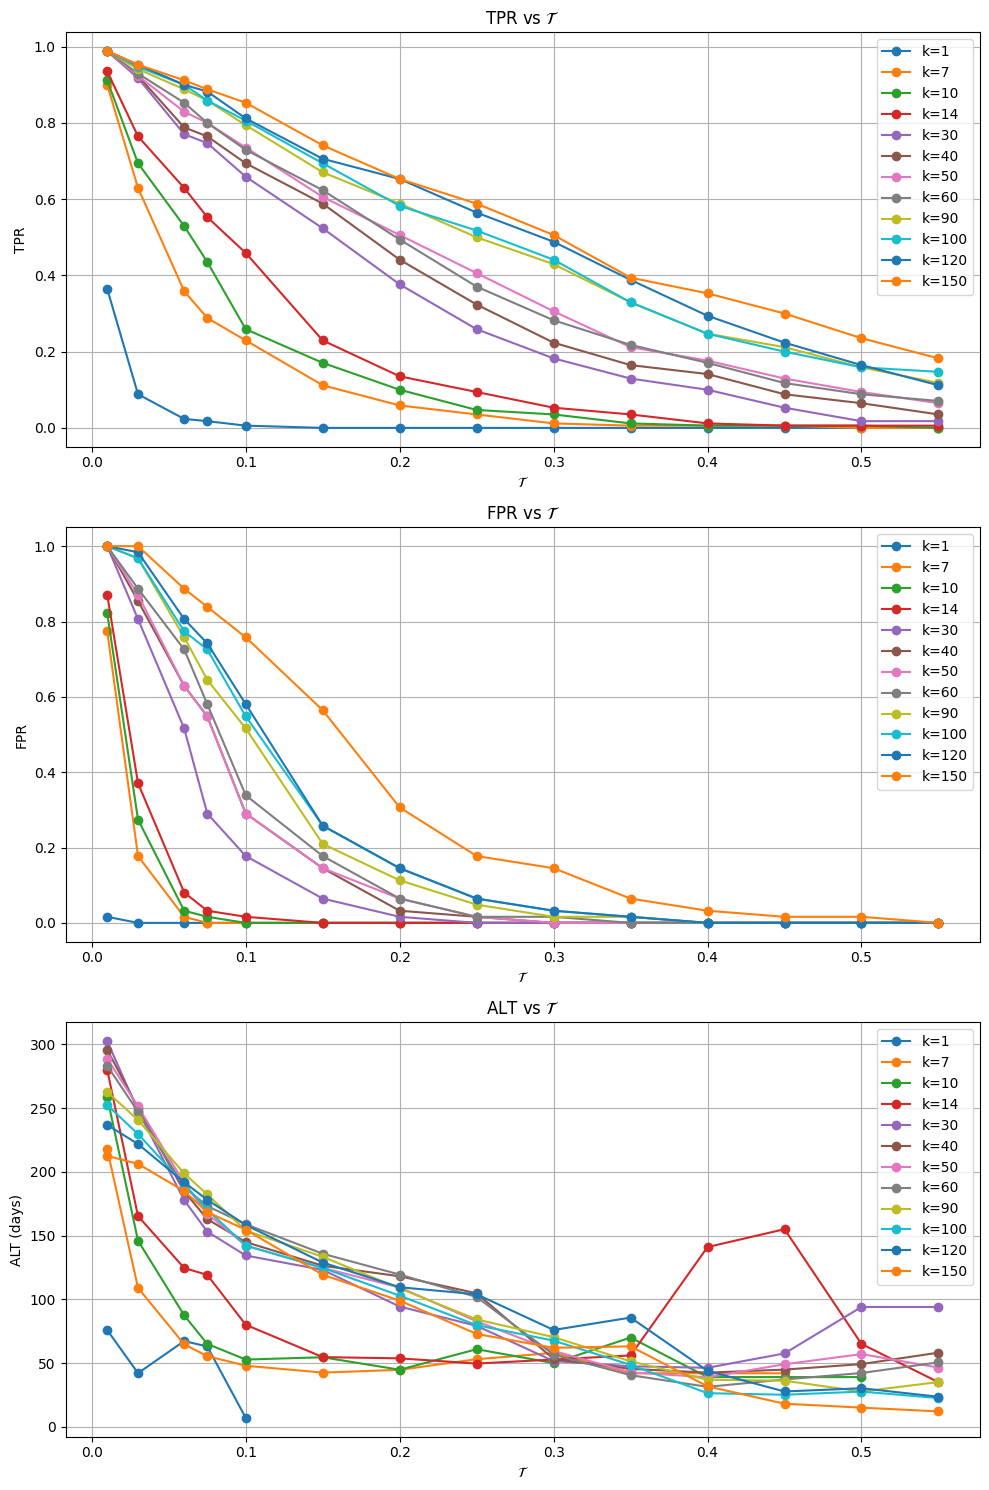

In [148]:
temp_df = result_df.copy()

temp_df.reset_index(inplace=True)
temp_df.rename(columns={"level_0": "threshold", "level_1": "k"}, inplace=True)
temp_df.sort_values(by=["threshold", "k"], inplace=True)
temp_df.reset_index(drop=True, inplace=True)

# temp_df.drop(temp_df[temp_df["k"] == 100].index, inplace=True)
temp_df.drop(temp_df[temp_df["k"] == 110].index, inplace=True)
temp_df.drop(temp_df[temp_df["k"] == 130].index, inplace=True)
temp_df.drop(temp_df[temp_df["k"] == 140].index, inplace=True)

plt.figure(figsize=(10, 15))

k_list = temp_df["k"].unique()

plt.subplot(3, 1, 1)
for k in k_list:
    subset = temp_df[temp_df["k"] == k]
    plt.plot(subset["threshold"], subset["Event detected rate"], marker='o', label=f'k={k}')

plt.title(r"TPR vs $\mathcal{T}$")
plt.legend()
plt.grid()
plt.xlabel(r"$\mathcal{T}$")
plt.ylabel("TPR")

plt.subplot(3, 1, 2)
for k in k_list:
    subset = temp_df[temp_df["k"] == k]
    plt.plot(subset["threshold"], subset["False alarms rate"], marker='o', label=f'k={k}')
plt.title(r"FPR vs $\mathcal{T}$")
plt.legend()
plt.grid()
plt.xlabel(r"$\mathcal{T}$")
plt.ylabel("FPR")

plt.subplot(3, 1, 3)
for k in k_list:
    subset = temp_df[temp_df["k"] == k]
    plt.plot(subset["threshold"], subset["Average lead time"], marker='o', label=f'k={k}')
plt.title(r"ALT vs $\mathcal{T}$")
plt.legend()
plt.grid()
plt.xlabel(r"$\mathcal{T}$")
plt.ylabel("ALT (days)")

plt.tight_layout()
plt.show()

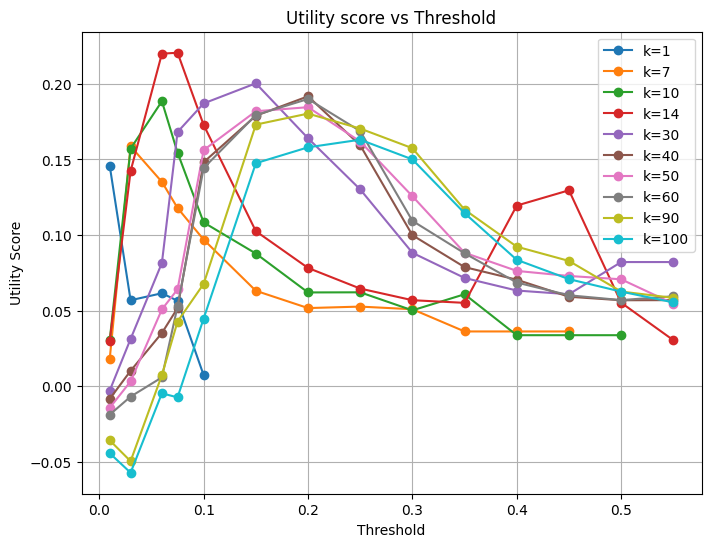

In [121]:
# Utility function to decide the best threshold and k based on the results
ALPHA_POS = 0.25     # Weight for event detected rate
ALPHA_NEG = 0.5    # Weight for false alarms rate
ALPHA_LEAD = 0.25   # Weight for average lead time

def compute_score(event_detected_rate, false_alarms_rate, average_lead_time):
    """
    Compute a score based on the event detected rate, false alarms rate, and average lead time.
    Higher scores indicate better performance.
    """
    # Compute the weighted score
    return ALPHA_POS * event_detected_rate - ALPHA_NEG * false_alarms_rate + ALPHA_LEAD * average_lead_time

temp_df["Scaled average lead time"] = temp_df["Average lead time"] / temp_df["Average lead time"].max()
temp_df["Score"] = temp_df.apply(lambda row: compute_score(row["Event detected rate"], row["False alarms rate"], row["Scaled average lead time"]), axis=1)

plt.figure(figsize=(8, 6))
for k in k_list:
    subset = temp_df[temp_df["k"] == k]
    plt.plot(subset["threshold"], subset["Score"], marker='o', label=f'k={k}')
plt.title("Utility score vs Threshold")
plt.legend()
plt.grid()
plt.xlabel("Threshold")
plt.ylabel("Utility Score")
plt.show()

### 4.3 Risk velocity

- **Idea**: Compute the risk velocity as the change in survival probability over time:
$$ V(t) = -\frac{dS(t)}{dt} $$

Max risk velocity for event cases: 0.1009
Max risk velocity for censored cases: 0.0051


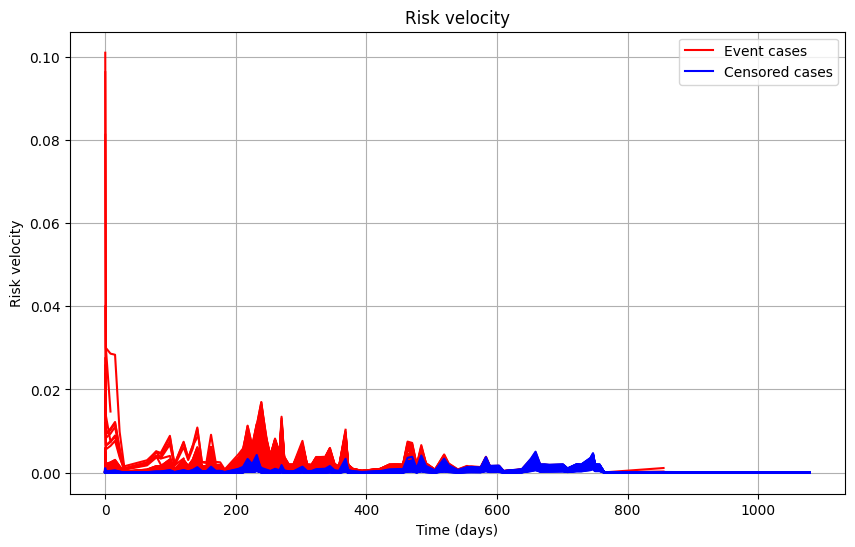

In [94]:
event_rows = idp_df[idp_df["status"] == 1]
censor_rows = idp_df[idp_df["status"] == 0]

plt.figure(figsize=(10, 6))

event_risk_velocity_lst = []
censor_risk_velocity_lst = []

for idx, row in event_rows.iterrows():
    iso_code = row["iso_code"]
    duration = row['duration']
    surv_df = survival_probabilities_dict[iso_code]

    surv_prob = surv_df["survival_probability"].to_numpy()
    surv_time = surv_df["time"].to_numpy()

    surv_diff = surv_prob[:-1] - surv_prob[1:]
    time_diff = surv_time[1:] - surv_time[:-1]

    risk_velocity = surv_diff / time_diff

    if len(risk_velocity) > 0:
        event_risk_velocity_lst.append(np.max(risk_velocity))

    plt.plot(surv_time[:-1], risk_velocity, color="red")

for idx, row in censor_rows.iterrows():
    iso_code = row["iso_code"]
    duration = row['duration']
    surv_df = survival_probabilities_dict[iso_code]

    surv_prob = surv_df["survival_probability"].to_numpy()
    surv_time = surv_df["time"].to_numpy()

    surv_diff = surv_prob[:-1] - surv_prob[1:]
    time_diff = surv_time[1:] - surv_time[:-1]

    risk_velocity = surv_diff / time_diff

    if len(risk_velocity) > 0:
        censor_risk_velocity_lst.append(np.max(risk_velocity))
    plt.plot(surv_time[:-1], risk_velocity, color="blue")

plt.grid()
plt.title("Risk velocity")
plt.xlabel("Time (days)")
plt.ylabel("Risk velocity")

plt.plot([], [], color="red", label="Event cases")
plt.plot([], [], color="blue", label="Censored cases")
plt.legend()

print(f"Max risk velocity for event cases: {np.max(event_risk_velocity_lst):.4f}")
print(f"Max risk velocity for censored cases: {np.max(censor_risk_velocity_lst):.4f}")

plt.show()

In [95]:
threshold = 1e-2

positive_cases = 0
negative_cases = 0
lead_times = []

for idx, row in event_rows.iterrows():
    iso_code = row["iso_code"]
    duration = row['duration']
    surv_df = survival_probabilities_dict[iso_code]

    surv_prob = surv_df["survival_probability"].to_numpy()
    surv_time = surv_df["time"].to_numpy()

    surv_diff = surv_prob[:-1] - surv_prob[1:]
    time_diff = surv_time[1:] - surv_time[:-1]

    risk_velocity = surv_diff / time_diff

    # Warning day is the first day when risk_velocity > threshold
    warning_idx = np.argmin(risk_velocity > threshold) if np.any(risk_velocity > threshold) else None
    if warning_idx is None:
        continue

    warning_day = surv_time[warning_idx+1]      # +1 because risk_velocity is one element shorter than surv_time
    positive_cases += 1
    lead_times.append(duration - warning_day)

for idx, row in censor_rows.iterrows():
    iso_code = row["iso_code"]
    duration = row['duration']
    surv_df = survival_probabilities_dict[iso_code]

    surv_prob = surv_df["survival_probability"].to_numpy()
    surv_time = surv_df["time"].to_numpy()

    surv_diff = surv_prob[:-1] - surv_prob[1:]
    time_diff = surv_time[1:] - surv_time[:-1]

    risk_velocity = surv_diff / time_diff

    # Warning day is the first day when risk_velocity > threshold
    warning_idx = np.argmin(risk_velocity > threshold) if np.any(risk_velocity > threshold) else None
    if warning_idx is not None:
        negative_cases += 1

print(f"Event detected rate: {positive_cases / len(event_rows):.2%}")
print(f"False alarms rate: {negative_cases / len(censor_rows):.2%}")
print(f"Average lead time: {np.mean(lead_times):.2f}")

Event detected rate: 22.94%
False alarms rate: 0.00%
Average lead time: 252.00
